### Simulation

In [1]:
from bmc.simulate import simulate
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
low = -1e-3
high = 1e-3

n_iso = 100

z_pos = np.linspace(low, high, n_iso)
z_pos = torch.tensor(z_pos)
z_pos = torch.cat((z_pos, torch.tensor([0.0])))  # Füge 0 hinzu
z_pos = torch.sort(z_pos).values

In [3]:
seq_path = 'seq_lib/90.seq'
config_path = 'sim_lib/config_1pool.yaml'

adc_time = 50e-3
retun_zmag = False
show_plot = False
n_backlog = 'ALL'
webhook = False
plt_range = [0, 4]
iso_select = [-5,0,5]

In [4]:
sim = simulate(config_file=config_path, 
                   seq_file=seq_path, 
                   adc_time=adc_time,
                   z_positions=z_pos,
                   return_zmag=retun_zmag,
                   iso_select=iso_select,
                   show_plot=show_plot,
                   n_backlog=n_backlog,
                   webhook=webhook,
                   plt_range=plt_range)  # simulation mac

BMCTool simulation: 100%|██████████| 3/3 [00:00<00:00, 12.34it/s]


222
torch.Size([101, 222])
['rf at 0.0000s', 'delay at 0.0020s', 'adc at 0.0120s']


/Users/danielmiksch/JupyterLab/optim/bmc/utils/eval.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


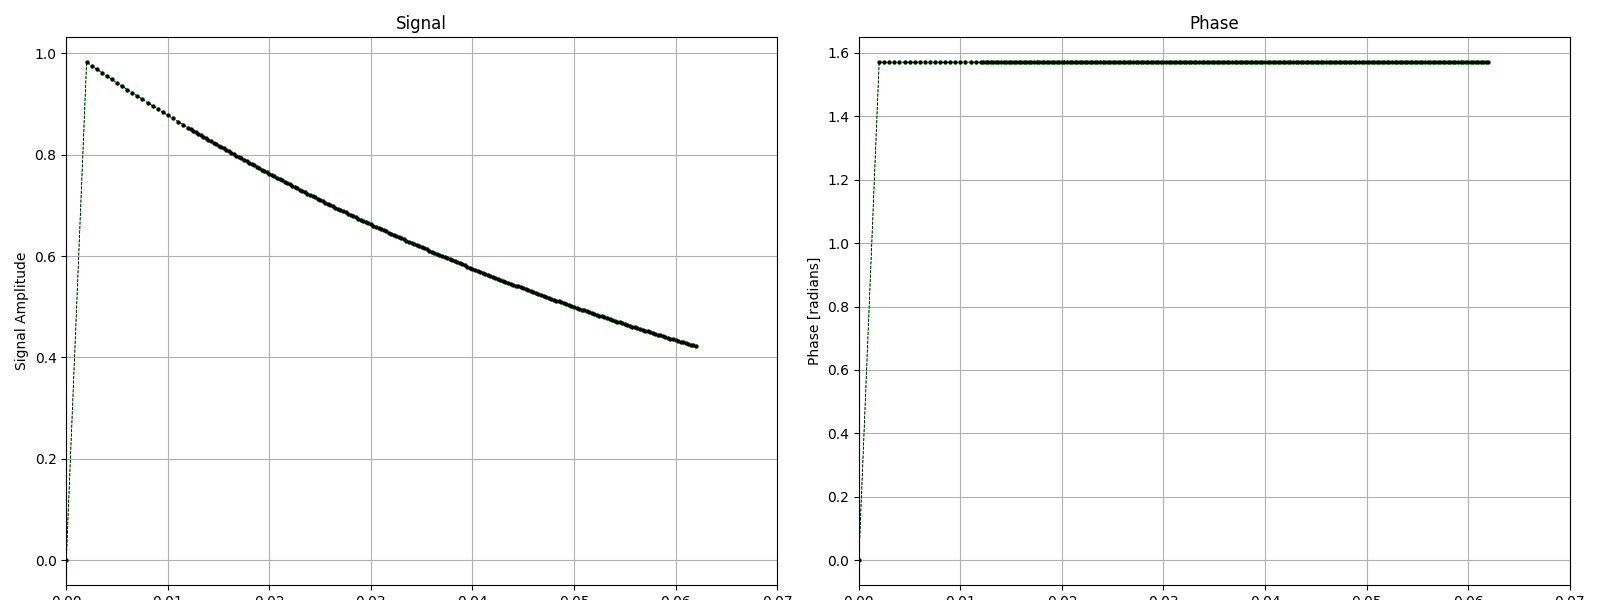

0.7705227311476854


In [5]:
%matplotlib widget
from bmc.utils.eval import plot_sim
time, m_z, m_z_total, m_c, m_c_total = sim.get_mag(return_cest_pool=False)
print(len(time))
print(m_c.shape)
time = time.cpu().numpy()
m_z = m_z.cpu().numpy()
m_z_total = m_z_total.cpu().numpy()
m_c = m_c.cpu().numpy()
m_c_total = m_c_total.cpu().numpy()

iso_select = [0]
# plt_range = [0.0, 0.0353] #1ETM
# plt_range = [0.07, 0.1]
# plt_range = [0.085, 0.0885]
# plt_range = [0.0, 0.01]
plt_range = [0.0, 0.07]

print(sim.events)

# _ = plot_sim(m_out=[m_z, m_z_total], time=time., plt_range=plt_range, iso_select=iso_select)
_ = plot_sim(m_out=[m_c, m_c_total], time=time, plt_range=plt_range, iso_select=iso_select)

m_trans_plus = np.abs(m_c_total)
m_z_plus = m_z_total
print(np.max(m_trans_plus[50:]))

### Ergebnisse speichern

In [6]:
from bmc.utils.results import save_simulation, load_simulation, list_simulations

# Label beschreibt kurz die Sequenz / das Experiment
result_dir = save_simulation(sim, label="30phasead_animation")
print(f"Gespeichert in: {result_dir}")


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/30phasead_animation_20260419_135840
Gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/30phasead_animation_20260419_135840


### Ergebnisse laden (Reproduzierbarkeit)

In [7]:
# Alle vorhandenen Simulationen auflisten
sims = list_simulations()
for s in sims:
    print(s.name)


30phasead_animation_20260419_135840


In [8]:
# Letztes (oder spezifisches) Ergebnis laden und Daten wiederherstellen
loaded = load_simulation(sims[-1])  # sims[-1] = neueste Simulation

m_out_loaded      = loaded["m_out"]              # (n_iso, n_states, n_time)
t_loaded          = loaded["t"]                  # Zeitarray
z_pos_loaded      = loaded["z_positions"]        # isochromate Positionen
events_loaded     = loaded["events"]
meta              = loaded["metadata"]

print(f"Sequenz:        {meta['seq_file']}")
print(f"Datum:          {meta['date']}")
print(f"Isochromaten:   {meta['n_isochromats']}")
print(f"Zeitpunkte:     {meta['n_timepoints']}")
print(f"m_out Shape:    {m_out_loaded.shape}")


Sequenz:        /Users/danielmiksch/JupyterLab/optim/seq_lib/90.seq
Datum:          2026-04-19T13:58:40.194021
Isochromaten:   101
Zeitpunkte:     421
m_out Shape:    (101, 3, 421)
